# Capítulo 4 - Resultados e Discussão (Clareza de Ganhos)

Este notebook foi estruturado para responder de forma direta: **onde está o ganho de tempo**, **quanto ele representa** e **se o sistema cumpre metas de espera**.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

BASE = Path('.')
META_ESPERA_MIN = 15.0  # meta de referência para leitura executiva

kpi_cenario = pd.read_csv(BASE / 'kpi_por_cenario.csv')
kpi_prioridade = pd.read_csv(BASE / 'kpi_por_prioridade.csv')
kpi_score = pd.read_csv(BASE / 'kpi_por_pontuacao_prioridade.csv')
logs = pd.read_csv(BASE / 'logs_atendimento_real_tese.csv')
validacao = pd.read_csv(BASE / 'validacao_hipoteses.csv')

cenarios_ordem = ['Cenario_A', 'Cenario_B', 'Cenario_C']
ordem_tipos = ['urgente', 'prioritario', 'normal']
ordem_faixas = ['baixa_0_2', 'media_3_4', 'alta_5_plus']

for df in [kpi_cenario, kpi_prioridade, kpi_score, logs]:
    for c in [x for x in df.columns if x.endswith('_seg') or x.endswith('_min') or x.startswith('taxa_')]:
        df[c] = pd.to_numeric(df[c], errors='coerce')

for df in [kpi_cenario, kpi_prioridade, kpi_score, logs]:
    if 'cenario' in df.columns:
        df['cenario'] = pd.Categorical(df['cenario'], categories=cenarios_ordem, ordered=True)

if 'tipo_atendimento' in kpi_prioridade.columns:
    kpi_prioridade['tipo_atendimento'] = pd.Categorical(kpi_prioridade['tipo_atendimento'], categories=ordem_tipos, ordered=True)
if 'tipo_atendimento' in logs.columns:
    logs['tipo_atendimento'] = pd.Categorical(logs['tipo_atendimento'], categories=ordem_tipos, ordered=True)
if 'faixa_prioridade' in kpi_score.columns:
    kpi_score['faixa_prioridade'] = pd.Categorical(kpi_score['faixa_prioridade'], categories=ordem_faixas, ordered=True)

print('Dados carregados.')


Dados carregados.


## 1) Quadro-resumo para o texto (números principais)


In [2]:
tabela_41 = kpi_cenario[[
    'cenario', 'total', 'concluidos', 'cancelados',
    'taxa_sucesso_autenticacao', 'taxa_sucesso_finalizacao',
    'espera_media_min', 'espera_mediana_min', 'espera_p95_min',
    'atendimento_media_min', 'atendimento_p95_min'
]].sort_values('cenario').reset_index(drop=True)

tabela_41['taxa_cancelamento'] = (tabela_41['cancelados'] / tabela_41['total']).round(4)
tabela_41


,cenario,total,concluidos,cancelados,taxa_sucesso_autenticacao,taxa_sucesso_finalizacao,espera_media_min,espera_mediana_min,espera_p95_min,atendimento_media_min,atendimento_p95_min,taxa_cancelamento
0,Cenario_A,90,82,8,0.911111,0.911111,12.53,0.0,48.08,4.51,5.90,0.0889
1,Cenario_B,120,107,13,0.891667,0.891667,24.13,0.0,111.56,7.20,9.77,0.1083
2,Cenario_C,180,158,22,0.877778,0.877778,54.35,0.0,211.59,9.84,13.79,0.1222


## 2) O sistema cumpre a meta de espera (15 min)?

Leitura: média, mediana e P95 por cenário com linha de meta.


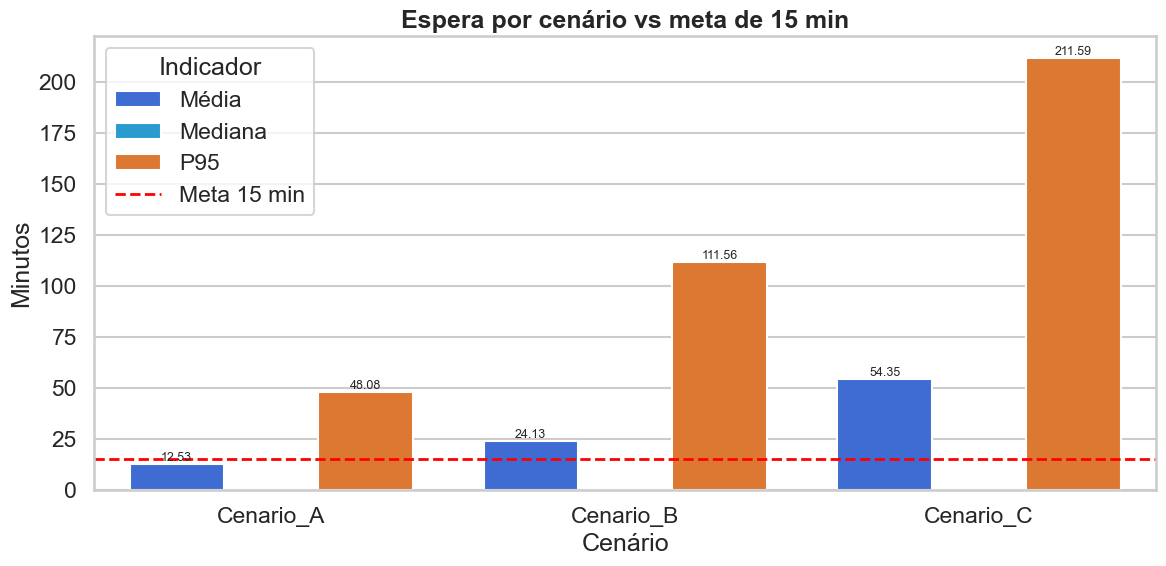

In [3]:
plot_meta = tabela_41[['cenario', 'espera_media_min', 'espera_mediana_min', 'espera_p95_min']].melt(
    id_vars='cenario', var_name='indicador', value_name='minutos'
)
mapa_ind = {
    'espera_media_min': 'Média',
    'espera_mediana_min': 'Mediana',
    'espera_p95_min': 'P95'
}
plot_meta['indicador'] = plot_meta['indicador'].map(mapa_ind)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_meta, x='cenario', y='minutos', hue='indicador', ax=ax,
            palette=['#2563eb', '#0ea5e9', '#f97316'])
ax.axhline(META_ESPERA_MIN, color='red', linestyle='--', linewidth=2, label=f'Meta {META_ESPERA_MIN:.0f} min')
ax.set_title('Espera por cenário vs meta de 15 min')
ax.set_xlabel('Cenário')
ax.set_ylabel('Minutos')
ax.legend(title='Indicador')

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width()/2, h), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [4]:
# Percentagem de utentes dentro da meta de 15 minutos (mais claro para decisão)
inside_meta = (
    logs.assign(dentro_meta=lambda d: d['espera_min'] <= META_ESPERA_MIN)
        .groupby('cenario', observed=True)['dentro_meta']
        .mean()
        .mul(100)
        .reset_index(name='pct_dentro_meta')
        .sort_values('cenario')
)
inside_meta


,cenario,pct_dentro_meta
0,Cenario_A,66.666667
1,Cenario_B,63.333333
2,Cenario_C,58.888889


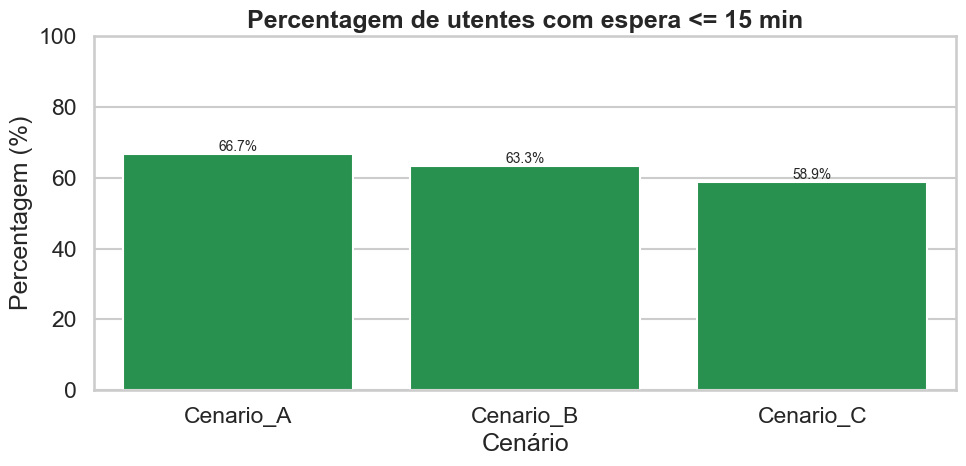

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=inside_meta, x='cenario', y='pct_dentro_meta', color='#16a34a', ax=ax)
ax.set_title('Percentagem de utentes com espera <= 15 min')
ax.set_xlabel('Cenário')
ax.set_ylabel('Percentagem (%)')
ax.set_ylim(0, 100)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2, h), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


## 3) Onde está o ganho do tempo? (efeito da prioridade)

Leitura: quanto `urgente` e `prioritario` esperam menos que `normal` em cada cenário.


In [6]:
base = kpi_prioridade[['cenario', 'tipo_atendimento', 'espera_media_min']].copy()
pivot = base.pivot_table(index='cenario', columns='tipo_atendimento', values='espera_media_min', aggfunc='mean')

# ganho (%) em relação ao normal: positivo significa redução de espera
pivot['ganho_urgente_vs_normal_%'] = ((pivot['normal'] - pivot['urgente']) / pivot['normal']) * 100
pivot['ganho_prioritario_vs_normal_%'] = ((pivot['normal'] - pivot['prioritario']) / pivot['normal']) * 100

ganhos = pivot[['ganho_urgente_vs_normal_%', 'ganho_prioritario_vs_normal_%']].reset_index()
ganhos


tipo_atendimento,cenario,ganho_urgente_vs_normal_%,ganho_prioritario_vs_normal_%
0,Cenario_A,72.675159,55.668790
1,Cenario_B,56.180068,53.473849
2,Cenario_C,66.250394,44.800084


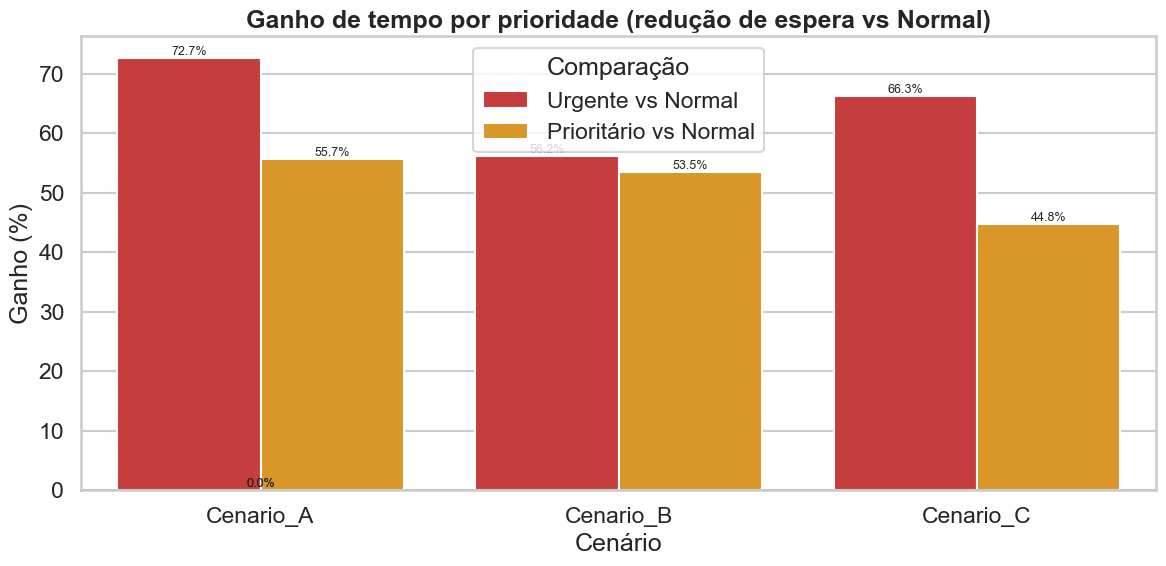

In [7]:
g = ganhos.melt(id_vars='cenario', var_name='comparacao', value_name='ganho_pct')
mapa = {
    'ganho_urgente_vs_normal_%': 'Urgente vs Normal',
    'ganho_prioritario_vs_normal_%': 'Prioritário vs Normal'
}
g['comparacao'] = g['comparacao'].map(mapa)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=g, x='cenario', y='ganho_pct', hue='comparacao', ax=ax, palette=['#dc2626', '#f59e0b'])
ax.set_title('Ganho de tempo por prioridade (redução de espera vs Normal)')
ax.set_xlabel('Cenário')
ax.set_ylabel('Ganho (%)')
ax.axhline(0, color='black', linewidth=1)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2, h), ha='center', va='bottom', fontsize=9)
ax.legend(title='Comparação')
plt.tight_layout()
plt.show()


## 4) Robustez operacional (conclusão, cancelamento e hipóteses)


In [8]:
robustez = tabela_41[['cenario', 'taxa_sucesso_autenticacao', 'taxa_sucesso_finalizacao', 'taxa_cancelamento']].copy()
robustez


,cenario,taxa_sucesso_autenticacao,taxa_sucesso_finalizacao,taxa_cancelamento
0,Cenario_A,0.911111,0.911111,0.0889
1,Cenario_B,0.891667,0.891667,0.1083
2,Cenario_C,0.877778,0.877778,0.1222


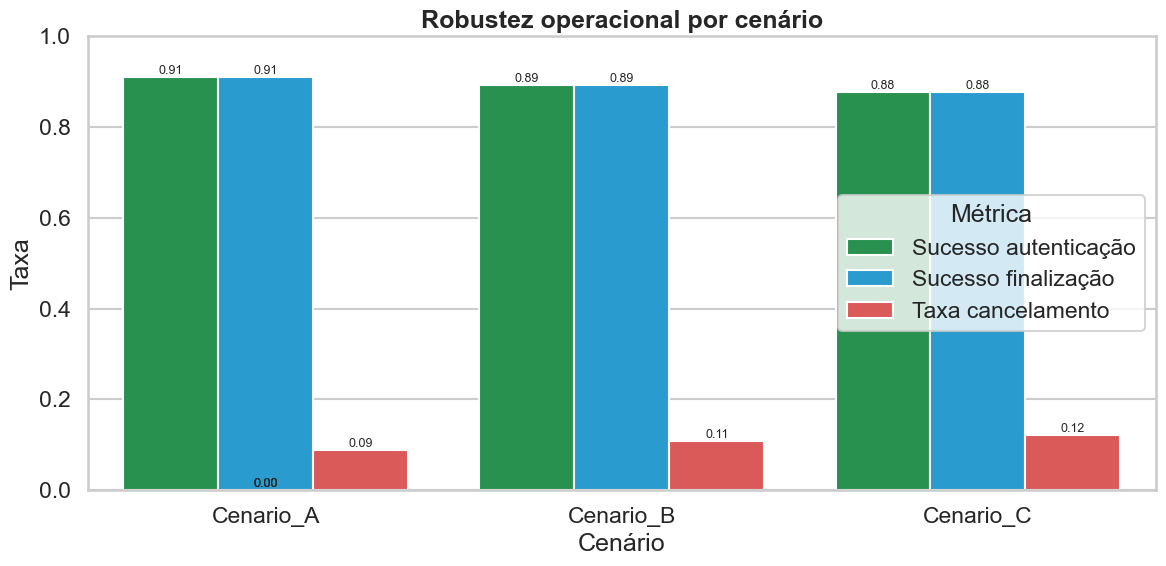

In [9]:
plot_rob = robustez.melt(id_vars='cenario', var_name='metrica', value_name='valor')
mapa_met = {
    'taxa_sucesso_autenticacao': 'Sucesso autenticação',
    'taxa_sucesso_finalizacao': 'Sucesso finalização',
    'taxa_cancelamento': 'Taxa cancelamento'
}
plot_rob['metrica'] = plot_rob['metrica'].map(mapa_met)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_rob, x='cenario', y='valor', hue='metrica', ax=ax,
            palette=['#16a34a', '#0ea5e9', '#ef4444'])
ax.set_title('Robustez operacional por cenário')
ax.set_xlabel('Cenário')
ax.set_ylabel('Taxa')
ax.set_ylim(0, 1)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width()/2, h), ha='center', va='bottom', fontsize=9)
ax.legend(title='Métrica')
plt.tight_layout()
plt.show()


In [10]:
validacao


,verificacao,violacoes,resultado
0,H1_done_requer_auth_e_finish,0,OK
1,H2_trilha_completa,0,OK
2,H3_fairness_score_Cenario_A,0,OK
3,H3_fairness_score_Cenario_B,0,OK
4,H3_fairness_score_Cenario_C,0,OK


## 5) Texto automático para colar no Capítulo 4


In [11]:
a = tabela_41.loc[tabela_41['cenario'] == 'Cenario_A'].iloc[0]
b = tabela_41.loc[tabela_41['cenario'] == 'Cenario_B'].iloc[0]
c = tabela_41.loc[tabela_41['cenario'] == 'Cenario_C'].iloc[0]

print('Resumo de espera (média / P95, em minutos):')
print(f"- Cenario_A: {a['espera_media_min']:.2f} / {a['espera_p95_min']:.2f}")
print(f"- Cenario_B: {b['espera_media_min']:.2f} / {b['espera_p95_min']:.2f}")
print(f"- Cenario_C: {c['espera_media_min']:.2f} / {c['espera_p95_min']:.2f}")

print('
Cumprimento da meta de 15 min (espera <= 15):')
for _, row in inside_meta.sort_values('cenario').iterrows():
    print(f"- {row['cenario']}: {row['pct_dentro_meta']:.1f}%")

print('
Ganho por prioridade (redução de espera vs normal):')
for _, row in ganhos.sort_values('cenario').iterrows():
    print(
        f"- {row['cenario']}: urgente={row['ganho_urgente_vs_normal_%']:.1f}% | "
        f"prioritario={row['ganho_prioritario_vs_normal_%']:.1f}%"
    )


SyntaxError: unterminated string literal (detected at line 10) (3606148879.py, line 10)